Using device: cpu
[integral-bundle] loaded 'integral_gaussian_L64_N3000_seed20250930.pt' | n=3000 L=64 kernel=gaussian
[integral-bundle] fingerprint: 3db847782db45780f0ecdb1e78a44016989b0855
Split sizes | train=2400, val=300, test=300
Softmax Attention: 232,726 parameters
Linear Attention: 213,526 parameters

Training Softmax Attention
Epoch   1/150 | train 0.025654 | val 0.000574 | t/epoch 20.437s | lr 0.001000
Epoch  10/150 | train 0.000159 | val 0.000210 | t/epoch 20.248s | lr 0.000989
Epoch  20/150 | train 0.000062 | val 0.000013 | t/epoch 19.887s | lr 0.000957
Epoch  30/150 | train 0.000046 | val 0.000024 | t/epoch 19.936s | lr 0.000905
Epoch  40/150 | train 0.000037 | val 0.000023 | t/epoch 20.538s | lr 0.000835
Epoch  50/150 | train 0.000096 | val 0.000079 | t/epoch 19.868s | lr 0.000750
Epoch  60/150 | train 0.000030 | val 0.000009 | t/epoch 20.177s | lr 0.000655
Epoch  70/150 | train 0.000044 | val 0.000007 | t/epoch 19.951s | lr 0.000552
Epoch  80/150 | train 0.000032 | val 0

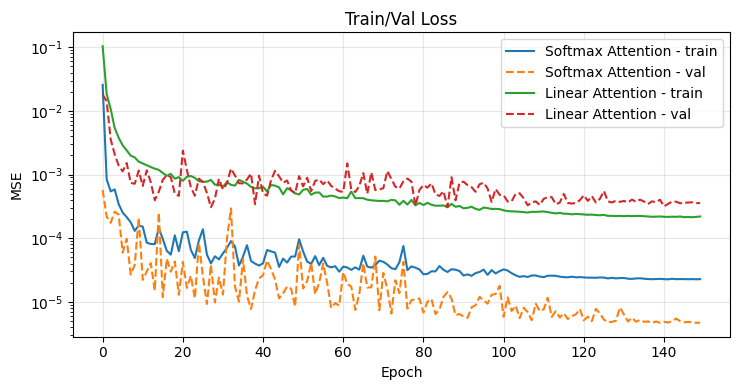

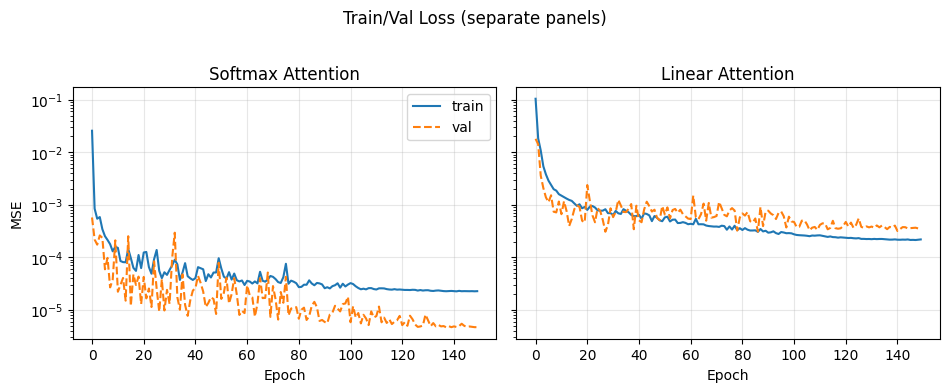

test MSE | Softmax Attention: 4.935135e-06
test MSE | Linear Attention: 3.708201e-04


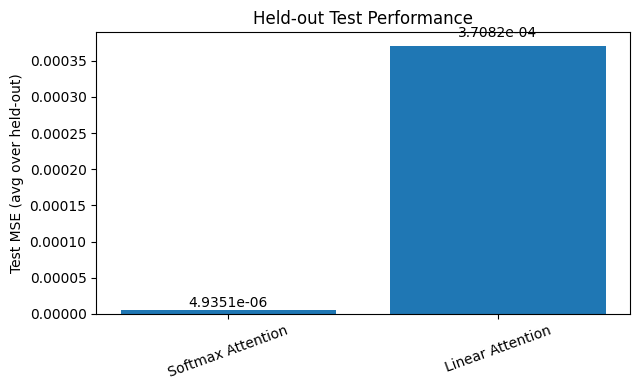


=== FLOPs (per forward, single sample) & Test MSE ===
Model                                    FLOPs     FLOPs(M)     Test MSE
Softmax Attention                     16721920       16.722   4.9351e-06
Linear Attention                      11400640       11.401   3.7082e-04


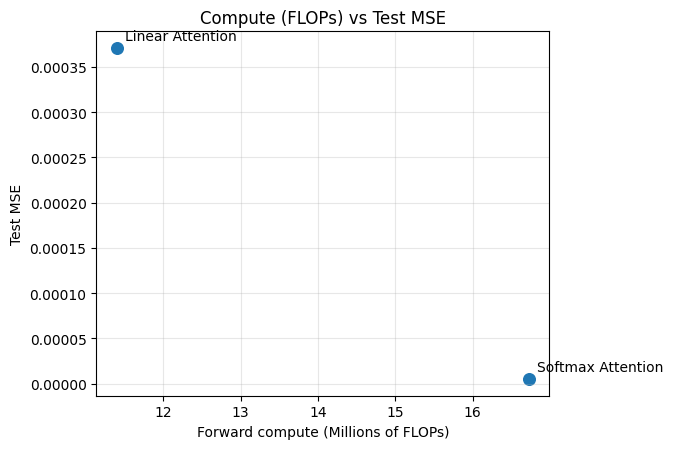


--- Testing at resolution 32 ---
  Softmax Attention: 0.044541
  Linear Attention: 2.855587

--- Testing at resolution 48 ---
  Softmax Attention: 0.026419
  Linear Attention: 0.229290

--- Testing at resolution 64 ---
  Softmax Attention: 0.019655
  Linear Attention: 0.102185

--- Testing at resolution 96 ---
  Softmax Attention: 0.018831
  Linear Attention: 0.243069

--- Testing at resolution 128 ---
  Softmax Attention: 0.021132
  Linear Attention: 0.267580

--- Testing at resolution 256 ---
  Softmax Attention: 0.026226
  Linear Attention: 0.285105


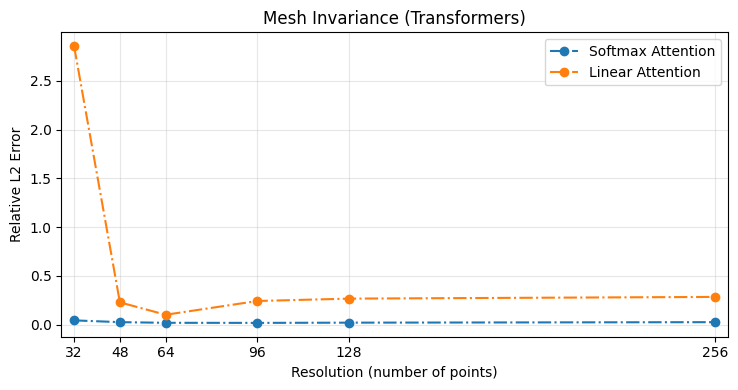

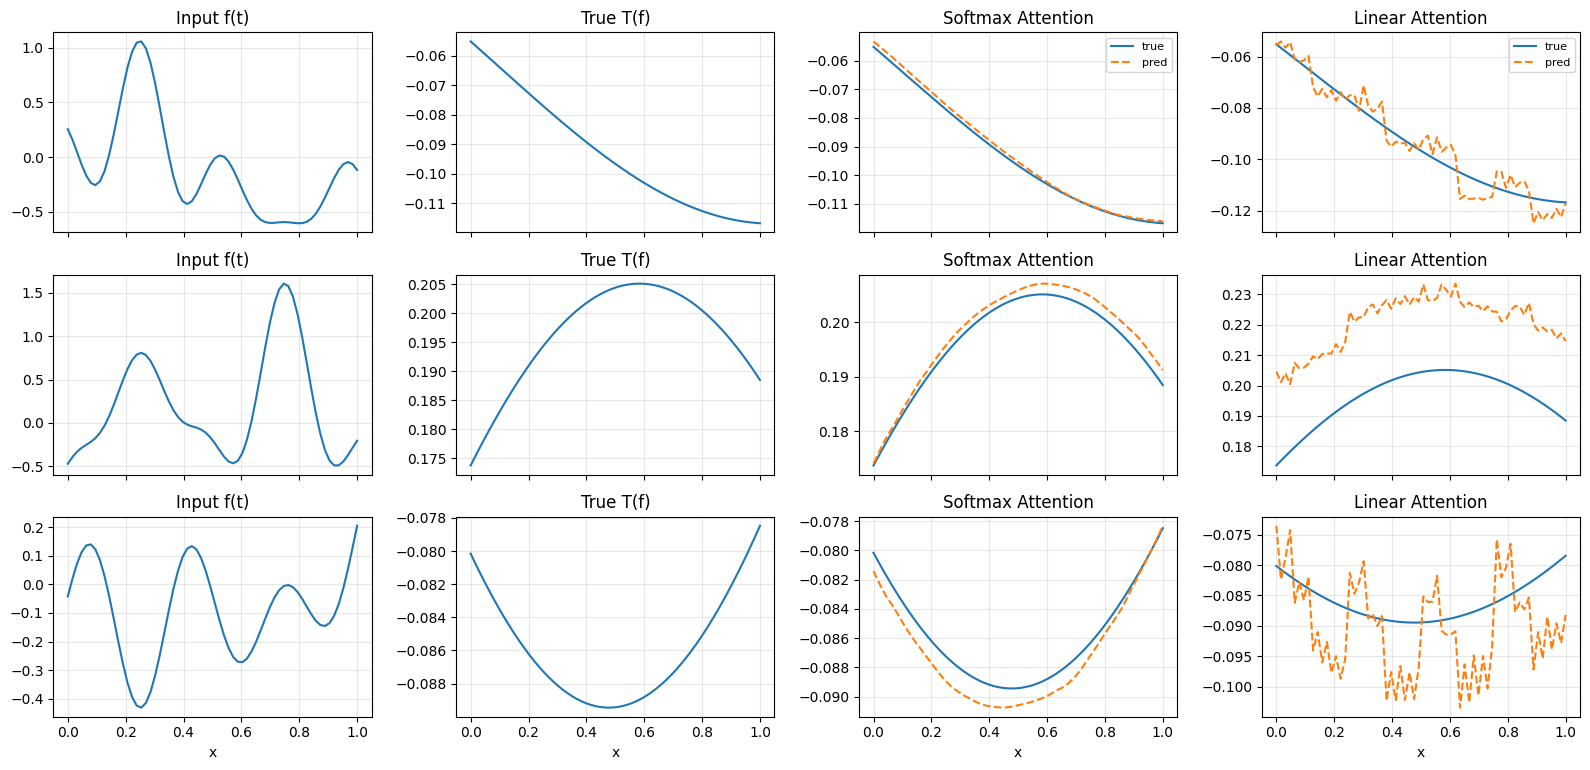

In [ ]:
import time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

import os, hashlib

class FrozenIntegralDataset(torch.utils.data.Dataset):

    def __init__(self, bundle):
        self.functions = bundle["functions"]        # (N, L)
        self.outputs   = bundle["outputs"]          # (N, L)
        self.n_points  = int(bundle["n_points"])
        self.kernel_type = str(bundle["kernel_type"])
        self.fingerprint = bundle.get("fingerprint", None)

    def __len__(self): return self.functions.shape[0]
    def __getitem__(self, idx):
        return self.functions[idx], self.outputs[idx]

def _bundle_fingerprint(functions: torch.Tensor, first_idxs=(0,1,2,10,222,333)):
    h = hashlib.sha1()
    for i in first_idxs:
        if i < 0 or i >= functions.shape[0]: continue
        h.update(functions[i].detach().cpu().numpy().astype(np.float32).tobytes())
    return h.hexdigest()

def get_or_create_frozen_testset(path: str, *,
                                 n_samples: int,
                                 n_points: int,
                                 kernel_type: str,
                                 sample_seed: int):
    """
    If file exists, load and return a FrozenIntegralDataset.
    Else, generate a test dataset deterministically and save it once.

    """
    if os.path.exists(path):
        bundle = torch.load(path, map_location="cpu")
        ds = FrozenIntegralDataset(bundle)
        print(f"[frozen-testset] loaded '{path}' | n={len(ds)} L={ds.n_points} kernel={ds.kernel_type}")
        if "fingerprint" in bundle:
            print("[frozen-testset] fingerprint:", bundle["fingerprint"])
        return ds

    # Generate deterministically using the private generator in your dataset
    gen_ds = IntegralOperatorDataset(n_samples=n_samples, n_points=n_points,
                                     kernel_type=kernel_type, sample_seed=sample_seed)
    bundle = {
        "functions": gen_ds.functions.clone().cpu(),
        "outputs":   gen_ds.outputs.clone().cpu(),
        "n_points":  int(n_points),
        "kernel_type": str(kernel_type),
    }
    bundle["fingerprint"] = _bundle_fingerprint(bundle["functions"])
    torch.save(bundle, path)
    print(f"[frozen-testset] created '{path}' | n={n_samples} L={n_points} kernel={kernel_type}")
    print("[frozen-testset] fingerprint:", bundle["fingerprint"])
    return FrozenIntegralDataset(bundle)


# Repro
torch.manual_seed(42)
np.random.seed(42)

# Dataset: Integral operator T(f)(x) = \int_0^1 K(x,t) f(t) dt
class IntegralOperatorDataset(Dataset):
    def __init__(self, n_samples=2000, n_points=64, kernel_type='gaussian', sample_seed=None):
        self.n_samples = n_samples
        self.n_points  = n_points
        self.x = torch.linspace(0, 1, n_points)
        self.t = torch.linspace(0, 1, n_points)
        self.kernel_type = kernel_type

        X, T = torch.meshgrid(self.x, self.t, indexing='ij')
        if kernel_type == 'gaussian':
            self.kernel = torch.exp(- (X - T)**2 / 2)
        elif kernel_type == 'exponential':
            self.kernel = torch.exp(-5 * torch.abs(X - T))
        elif kernel_type == 'polynomial':
            self.kernel = (1 + X * T) * torch.exp(-2 * (X - T)**2)
        else:
            raise ValueError(f"Unknown kernel_type: {kernel_type}")


        self.dt = 1.0 / (self.n_points - 1)
        self.w = torch.full((self.n_points,), self.dt)
        self.w[0] *= 0.5
        self.w[-1] *= 0.5


        self._sample_gen = None
        if sample_seed is not None:
            self._sample_gen = torch.Generator()
            self._sample_gen.manual_seed(int(sample_seed))
        # Prepare data
        self.functions, self.outputs = self._generate_data()

    def _sample_function(self):
        if self._sample_gen is None:
            coeffs = torch.randn(8) * 0.3
        else:
            coeffs = torch.randn(8, generator=self._sample_gen) * 0.3


        f = (coeffs[0] * torch.sin(2 * np.pi * self.t) +
             coeffs[1] * torch.cos(4 * np.pi * self.t) +
             coeffs[2] * torch.exp(-8 * (self.t - 0.3)**2) +
             coeffs[3] * torch.exp(-8 * (self.t - 0.7)**2) +
             coeffs[4] * self.t * (1 - self.t) +
             coeffs[5] * torch.sin(6 * np.pi * self.t) +
             coeffs[6] * (self.t - 0.5)**3 +
             coeffs[7] * torch.cos(8 * np.pi * self.t))
        return f

    def _generate_data(self):
        functions, outputs = [], []
        for _ in range(self.n_samples):
            f = self._sample_function()
            integrand = self.kernel * f.unsqueeze(0)  # [n_points, n_points]
            # trapz along t-axis (dim=1)
            out = torch.trapz(integrand, dx=self.dt, dim=1)
            functions.append(f)
            outputs.append(out)
        return torch.stack(functions), torch.stack(outputs)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.functions[idx], self.outputs[idx]


    def _compute_true_output(self, f):
        f = f.to(self.kernel.device)
        integrand = self.kernel * f.unsqueeze(0)  # [n_points, n_points]
        out = torch.trapz(integrand, dx=self.dt, dim=1)
        return out.cpu()




def eval_integral_basis(coeffs: torch.Tensor, n_points: int) -> torch.Tensor:

    single = coeffs.dim() == 1
    if single:
        coeffs = coeffs.unsqueeze(0)

    t = torch.linspace(0, 1, n_points, dtype=coeffs.dtype, device=coeffs.device)
    f = (
        coeffs[:, 0:1] * torch.sin(2 * np.pi * t)
        + coeffs[:, 1:2] * torch.cos(4 * np.pi * t)
        + coeffs[:, 2:3] * torch.exp(-8 * (t - 0.3) ** 2)
        + coeffs[:, 3:4] * torch.exp(-8 * (t - 0.7) ** 2)
        + coeffs[:, 4:5] * t * (1 - t)
        + coeffs[:, 5:6] * torch.sin(6 * np.pi * t)
        + coeffs[:, 6:7] * (t - 0.5) ** 3
        + coeffs[:, 7:8] * torch.cos(8 * np.pi * t)
    )
    return f.squeeze(0) if single else f


def make_kernel_1d(n_points: int, kernel_type: str = 'gaussian', device=None, dtype=torch.float32) -> torch.Tensor:
    x = torch.linspace(0, 1, n_points, device=device, dtype=dtype)
    t = torch.linspace(0, 1, n_points, device=device, dtype=dtype)
    X, T = torch.meshgrid(x, t, indexing='ij')

    if kernel_type == 'gaussian':
        return torch.exp(-((X - T) ** 2) / 2)
    if kernel_type == 'exponential':
        return torch.exp(-5 * torch.abs(X - T))
    if kernel_type == 'polynomial':
        return (1 + X * T) * torch.exp(-2 * (X - T) ** 2)
    raise ValueError(f"Unknown kernel_type: {kernel_type}")


def apply_integral_operator(f: torch.Tensor, kernel_type: str = 'gaussian') -> torch.Tensor:

    single = f.dim() == 1
    if single:
        f = f.unsqueeze(0)

    n_points = f.shape[-1]
    K = make_kernel_1d(n_points, kernel_type, device=f.device, dtype=f.dtype)
    dt = 1.0 / (n_points - 1)
    integrand = K.unsqueeze(0) * f.unsqueeze(1)  # (N, Lx, Lt)
    out = torch.trapz(integrand, dx=dt, dim=2)
    return out.squeeze(0) if single else out


class IntegralBundleDataset(torch.utils.data.Dataset):

    def __init__(self, bundle: dict, split: str | None = None):
        self.coeffs = bundle['coeffs']
        self.functions = bundle['functions']
        self.outputs = bundle['outputs']
        self.n_points = int(bundle['n_points'])
        self.kernel_type = str(bundle['kernel_type'])
        self.fingerprint = bundle.get('fingerprint', None)

        if split is None:
            self.indices = torch.arange(len(self.functions), dtype=torch.long)
        else:
            self.indices = bundle['splits'][split].long()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        return self.functions[real_idx], self.outputs[real_idx]

    def get_coeffs(self, idx):
        real_idx = int(self.indices[idx])
        return self.coeffs[real_idx]


def get_or_create_integral_bundle(path: str, *,
                                  n_samples: int,
                                  n_points: int,
                                  kernel_type: str,
                                  sample_seed: int,
                                  split_seed: int = 123,
                                  train_ratio: float = 0.8,
                                  val_ratio: float = 0.1):

    if os.path.exists(path):
        bundle = torch.load(path, map_location='cpu')
        print(f"[integral-bundle] loaded '{path}' | n={bundle['functions'].shape[0]} L={bundle['n_points']} kernel={bundle['kernel_type']}")
        if 'fingerprint' in bundle:
            print('[integral-bundle] fingerprint:', bundle['fingerprint'])
        return bundle

    gen = torch.Generator().manual_seed(int(sample_seed))
    coeffs = torch.randn(n_samples, 8, generator=gen) * 0.3
    functions = eval_integral_basis(coeffs, n_points)
    outputs = apply_integral_operator(functions, kernel_type)

    split_gen = torch.Generator().manual_seed(int(split_seed))
    perm = torch.randperm(n_samples, generator=split_gen)
    n_train = int(train_ratio * n_samples)
    n_val = int(val_ratio * n_samples)

    bundle = {
        'coeffs': coeffs.cpu(),
        'functions': functions.cpu(),
        'outputs': outputs.cpu(),
        'n_points': int(n_points),
        'kernel_type': str(kernel_type),
        'sample_seed': int(sample_seed),
        'split_seed': int(split_seed),
        'splits': {
            'train': perm[:n_train].cpu(),
            'val': perm[n_train:n_train + n_val].cpu(),
            'test': perm[n_train + n_val:].cpu(),
        },
    }
    bundle['fingerprint'] = _bundle_fingerprint(bundle['functions'])
    torch.save(bundle, path)
    print(f"[integral-bundle] created '{path}' | n={n_samples} L={n_points} kernel={kernel_type}")
    print(f"[integral-bundle] split sizes: train={n_train}, val={n_val}, test={n_samples - n_train - n_val}")
    print('[integral-bundle] fingerprint:', bundle['fingerprint'])
    return bundle

# Transformers (Softmax & Linear)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        self.register_buffer(
            'div_term',
            torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        )
        self.alpha = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):  # x: (B, L, d_model)
        B, L, D = x.shape
        s = torch.linspace(0.0, 1.0, L, device=x.device).unsqueeze(1)   # (L,1) continuous coord
        pe = torch.zeros(L, D, device=x.device)
        pe[:, 0::2] = torch.sin(s * self.div_term)
        pe[:, 1::2] = torch.cos(s * self.div_term)
        return x + self.alpha * pe.unsqueeze(0)

class SoftmaxMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads=8, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)
    def forward(self, query, key, value):
        B, L, _ = query.size()
        Q = self.W_q(query).view(B, L, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key)  .view(B, L, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(B, L, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        context = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, L, self.d_model)
        return self.W_o(context)

# Linear Attention: Y = (1/N) * X * X^T * W * X (per head), bilinear in X
class LinearSelfAttn(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.0, sym_W: bool = True):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.sym_W   = sym_W
        self.W = nn.Parameter(torch.empty(n_heads, self.d_head, self.d_head))
        nn.init.xavier_uniform_(self.W)
        self.out_proj = nn.Linear(d_model, d_model)
        self.drop     = nn.Dropout(dropout)

    def forward(self, x):  # x: (B, L, d_model)
        B, L, D = x.shape
        H, d = self.n_heads, self.d_head
        X = x.view(B, L, H, d).permute(0, 2, 3, 1)  # (B,H,d,L)
        XXT = torch.matmul(X, X.transpose(-1, -2))  # (B,H,d,d)
        W = self.W
        if self.sym_W:
            W = 0.5 * (W + W.transpose(-1, -2))      # (H,d,d)
        S = torch.matmul(XXT, W)                     # (B,H,d,d)
        Y = torch.matmul(S, X)                       # (B,H,d,L)
        Y = Y / (L if L > 0 else 1)
        Y = Y.permute(0, 1, 3, 2).contiguous().view(B, L, D)
        Y = self.drop(Y)
        return self.out_proj(Y)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, attention_type='softmax', dropout=0.1):
        super().__init__()
        if attention_type == 'softmax':
            self.attention = SoftmaxMultiHeadAttention(d_model, n_heads, dropout)
            self.attn_mode = 'qkv'
        elif attention_type == 'linear':
            self.attention = LinearSelfAttn(d_model, n_heads, dropout, sym_W=True)
            self.attn_mode = 'x'
        else:
            raise ValueError("attention_type must be 'softmax' or 'linear'")
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        attn_out = self.attention(x, x, x) if self.attn_mode == 'qkv' else self.attention(x)
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x

class SoftmaxTransformerOperator(nn.Module):
    def __init__(self, input_dim=64, d_model=80, n_heads=8, n_layers=3, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model, bias=False)
        self.pos_encoding = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, 'softmax', dropout) for _ in range(n_layers)])
        self.out = nn.Linear(d_model, 1)
        self.drop = nn.Dropout(dropout)
    def forward(self, f):  # f: [B, L]
        B, L = f.shape
        x = self.input_projection(f.unsqueeze(-1))
        x = self.pos_encoding(x)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.out(x).squeeze(-1)

class LinearTransformerOperator(nn.Module):
    def __init__(self, input_dim=64, d_model=80, n_heads=8, n_layers=4, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model, bias=False)
        self.pos_encoding = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, 'linear', dropout) for _ in range(n_layers)])
        self.out = nn.Linear(d_model, 1)
        self.drop = nn.Dropout(dropout)
    def forward(self, f):  # f: [B, L]
        B, L = f.shape
        x = self.input_projection(f.unsqueeze(-1))
        x = self.pos_encoding(x)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.out(x).squeeze(-1)


# Training / Eval utilities
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running = 0.0
    for f, y in loader:
        f, y = f.to(device), y.to(device)
        optimizer.zero_grad()
        yhat = model(f)
        loss = criterion(yhat, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item()
    return running / max(1, len(loader))

def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for f, y in loader:
            f, y = f.to(device), y.to(device)
            yhat = model(f)
            total += criterion(yhat, y).item()
    return total / max(1, len(loader))

def train_model(model, train_loader, val_loader, epochs=150, lr=1e-3, device='cpu'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    hist = {"train_loss": [], "val_loss": [], "epoch_time": [], "lr": []}
    for ep in range(1, epochs+1):
        t0 = time.perf_counter()
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        dt = time.perf_counter() - t0
        hist["train_loss"].append(tr)
        hist["val_loss"].append(va)
        hist["epoch_time"].append(dt)
        hist["lr"].append(optimizer.param_groups[0]['lr'])
        if ep % 10 == 0 or ep == 1:
            print(f"Epoch {ep:3d}/{epochs} | train {tr:.6f} | val {va:.6f} | t/epoch {dt:.3f}s | lr {hist['lr'][-1]:.6f}")
    return hist

# Plot helpers
def plot_train_val(histories, title_suffix=""):
    plt.figure(figsize=(7.5,4))
    for name, h in histories.items():
        plt.plot(h['train_loss'], label=f"{name} - train")
        plt.plot(h['val_loss'],   label=f"{name} - val", linestyle='--')
    plt.yscale('log')
    plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Train/Val Loss' + title_suffix)
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()

def plot_train_val_separate(histories, title_suffix=""):
    names = list(histories.keys())
    fig, axes = plt.subplots(1, len(names), figsize=(4.8*len(names), 3.8), sharey=True)
    if len(names) == 1:
        axes = [axes]
    for ax, name in zip(axes, names):
        h = histories[name]
        ax.plot(h['train_loss'], label='train')
        ax.plot(h['val_loss'], linestyle='--', label='val')
        ax.set_yscale('log')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('MSE')
    axes[0].legend()
    fig.suptitle('Train/Val Loss (separate panels)' + title_suffix, y=1.02, fontsize=12)
    plt.tight_layout()

def evaluate_on_dataset(model, dataset, n_eval=100, device='cpu'):
    model.eval()
    idxs = np.random.choice(len(dataset), n_eval, replace=False)
    se = 0.0
    with torch.no_grad():
        for idx in idxs:
            f, y = dataset[idx]
            f = f.to(device).unsqueeze(0)
            y_pred = model(f).squeeze(0).cpu()
            se += F.mse_loss(y_pred, y, reduction='mean').item()
    return se / n_eval



def evaluate_full_dataset(model, loader, device='cpu'):
    model.eval()
    se_sum = 0.0
    count = 0
    with torch.no_grad():
        for f, y in loader:
            f = f.to(device)
            y = y.to(device)
            y_pred = model(f)
            se_sum += F.mse_loss(y_pred, y, reduction='sum').item()
            count += y.numel()
    return se_sum / max(count, 1)

def bar_test_mse(results):
    names = list(results.keys())
    vals = [results[n] for n in names]
    plt.figure(figsize=(6.5,4))
    plt.bar(names, vals)
    for i,v in enumerate(vals):
        plt.text(i, v*1.02, f"{v:.4e}", ha='center', va='bottom')
    plt.ylabel('Test MSE (avg over held-out)')
    plt.title('Held-out Test Performance')
    plt.xticks(rotation=20)
    plt.tight_layout()

def plot_test_examples(models_or_model, dataset, n_show=4, device='cpu', idxs=None, seed=12345):

    if isinstance(models_or_model, dict):
        models = models_or_model
    else:
        models = {'Model': models_or_model}

    # 決定要畫哪些樣本
    if idxs is None:
        rng = np.random.default_rng(seed)
        idxs = rng.choice(len(dataset), n_show, replace=False)
    else:
        idxs = list(idxs)

    fig, axes = plt.subplots(n_show, len(models)+2, figsize=(4*(len(models)+2), 2.6*n_show), sharex=True)
    if n_show == 1:
        axes = axes.reshape(1, -1)
    xs = torch.linspace(0, 1, dataset.n_points)

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            f, y = dataset[int(idx)]
            axes[i,0].plot(xs, f); axes[i,0].set_title('Input f(t)'); axes[i,0].grid(True, alpha=0.3)
            axes[i,1].plot(xs, y); axes[i,1].set_title('True T(f)'); axes[i,1].grid(True, alpha=0.3)
            for j,(name, model) in enumerate(models.items(), start=2):
                yhat = model(f.unsqueeze(0).to(device)).squeeze(0).cpu()
                axes[i,j].plot(xs, y, label='true')
                axes[i,j].plot(xs, yhat, linestyle='--', label='pred')
                axes[i,j].set_title(name)
                axes[i,j].grid(True, alpha=0.3)
                if i == 0:
                    axes[i,j].legend(fontsize=8)
    for k in range(len(models)+2):
        axes[-1,k].set_xlabel('x')
    plt.tight_layout()


# Mesh-invariance utilities
def resample_1d(vec: torch.Tensor, new_len: int) -> torch.Tensor:
    dev, dt = vec.device, vec.dtype
    x = vec.view(1, 1, -1).to(dev)
    y = F.interpolate(x, size=new_len, mode='linear', align_corners=True)
    return y.view(-1).to(dev, dtype=dt)

def relative_l2_weighted_robust(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-12) -> float:
    L = pred.numel()
    if L == 0:
        return 0.0
    dx = 1.0 / max(1, L - 1)
    w = pred.new_ones(L)
    if L > 1:
        w[0] = 0.5
        w[-1] = 0.5
    def weighted_norm(x):
        return torch.sqrt(((x**2) * w).sum() * dx)
    pred_norm = weighted_norm(pred)
    target_norm = weighted_norm(target)
    diff_norm = weighted_norm(pred - target)
    if target_norm < eps:
        return diff_norm.item()
    else:
        return (diff_norm / (target_norm + eps)).item()

def relative_l2_weighted(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-12) -> float:
    return relative_l2_weighted_robust(pred, target, eps)


def mesh_invariance_benchmark_transformers(
    models: dict,
    kernel_type: str,
    grid_list,
    n_per_res: int,
    device,
    base_dataset=None,
):
    results = {name: [] for name in models.keys()}

    if base_dataset is not None:
        print("Using consistent test functions from base dataset...")
        test_functions = []
        for k in range(min(n_per_res, len(base_dataset))):
            f, _ = base_dataset[k]
            test_functions.append(f)
    for n_points in grid_list:
        print(f"\n--- Testing at resolution {n_points} ---")
        ds = IntegralOperatorDataset(n_samples=n_per_res, n_points=n_points, kernel_type=kernel_type)
        for name, model in models.items():
            model.eval()
            errs = []
            with torch.no_grad():
                for k in range(n_per_res):
                    if base_dataset is not None and k < len(test_functions):
                        f_base = test_functions[k]
                        f = resample_1d(f_base.cpu(), n_points).cpu()
                        y_true = ds._compute_true_output(f)
                    else:
                        f, y_true = ds[k]
                    y_hat = model(f.unsqueeze(0).to(device)).squeeze(0).cpu()
                    err = relative_l2_weighted(y_hat, y_true)
                    errs.append(err)
            avg_err = float(np.mean(errs))
            results[name].append(avg_err)
            print(f"  {name}: {avg_err:.6f}")
    return results




def mesh_invariance_from_coeffs(
    models: dict,
    test_dataset: IntegralBundleDataset,
    kernel_type: str,
    grid_list,
    n_per_res: int,
    device,
):
    results = {name: [] for name in models.keys()}
    n_use = min(int(n_per_res), len(test_dataset))
    coeffs = torch.stack([test_dataset.get_coeffs(i) for i in range(n_use)]).cpu()

    for n_points in grid_list:
        print(f"\n--- Testing at resolution {n_points} ---")
        f_test = eval_integral_basis(coeffs, int(n_points)).cpu()
        y_true = apply_integral_operator(f_test, kernel_type).cpu()

        for name, model in models.items():
            model.eval()
            errs = []
            with torch.no_grad():
                for i in range(n_use):
                    f = f_test[i].to(device).unsqueeze(0)
                    y_hat = model(f).squeeze(0).cpu()
                    err = relative_l2_weighted(y_hat, y_true[i])
                    errs.append(err)
            avg_err = float(np.mean(errs))
            results[name].append(avg_err)
            print(f"  {name}: {avg_err:.6f}")
    return results

def plot_mesh_invariance(grid_list, results: dict, title='Mesh Invariance (lower is better)'):
    fig, ax = plt.subplots(figsize=(7.5,4))
    for name, vals in results.items():
        ax.plot(grid_list, vals, marker='o', linestyle='-.', label=name)
    ax.set_xlabel('Resolution (number of points)')
    ax.set_ylabel('Relative L2 Error')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xticks(grid_list)
    ax.set_xticklabels([str(x) for x in grid_list])
    ax.margins(x=0.02)
    plt.tight_layout()


# FLOPs estimation + plot
def macs_softmax_transformer(seq_len: int, d_model: int, n_heads: int, n_layers: int) -> float:
    N, d, L = seq_len, d_model, n_layers
    # projections + attention matmul + FFN
    per_layer = 12*N*(d**2) + 2*(N**2)*d
    macs = L*per_layer + 2*N*d  # + IO projection
    return float(macs)

def macs_paper_linear_transformer(seq_len: int, d_model: int, n_heads: int, n_layers: int) -> float:
    N, d, h, L = seq_len, d_model, n_heads, n_layers
    per_layer = (9.0 + 2.0/h)*N*(d**2) + (d**3)/(h**2)
    macs = L*per_layer + 2*N*d
    return float(macs)

def estimate_model_macs(model, seq_len: int) -> float:

    attn = None
    n_layers = 0

    # Softmax/Linear
    if hasattr(model, "blocks") and len(model.blocks) > 0:
        first = model.blocks[0]
        for cand in ["attention", "self_attn", "cross", "cross_attn"]:
            if hasattr(first, cand):
                attn = getattr(first, cand)
                break
        n_layers = len(model.blocks)

    # 2) encoder–decoder
    if attn is None and hasattr(model, "enc_blocks") and len(model.enc_blocks) > 0:
        first = model.enc_blocks[0]
        for cand in ["attention", "self_attn"]:
            if hasattr(first, cand):
                attn = getattr(first, cand)
                break
        n_layers = len(model.enc_blocks) + (len(getattr(model, "dec_blocks", [])) if hasattr(model, "dec_blocks") else 0)

        # 試 decoder
        if attn is None and hasattr(model, "dec_blocks") and len(model.dec_blocks) > 0:
            first = model.dec_blocks[0]
            for cand in ["attention", "self_attn", "cross", "cross_attn"]:
                if hasattr(first, cand):
                    attn = getattr(first, cand)
                    break

    if attn is None:
        raise ValueError("Unknown model type for FLOPs estimation (no attention module found).")

    # d_model / n_heads
    d = getattr(attn, "d_model", None)
    if d is None and hasattr(model, "out") and hasattr(model.out, "in_features"):
        d = model.out.in_features
    if d is None:
        d = 128

    h = getattr(attn, "n_heads", 1)

    if isinstance(attn, (LinearSelfAttn, CrossAttentionLinear)):
        return macs_paper_linear_transformer(seq_len, d, h, n_layers)
    else:
        return macs_softmax_transformer(seq_len, d, h, n_layers)




def print_macs_table(models: dict, test_results: dict, seq_len: int):
    print("\n=== FLOPs (per forward, single sample) & Test MSE ===")
    print(f"{'Model':30s} {'FLOPs':>15s} {'FLOPs(M)':>12s} {'Test MSE':>12s}")
    for name, m in models.items():
        macs = estimate_model_macs(m, seq_len)
        print(f"{name:30s} {macs:15.0f} {macs/1e6:12.3f} {test_results.get(name, float('nan')):12.4e}")

def plot_flops_vs_mse(models: dict, test_results: dict, seq_len: int, title="FLOPs vs MSE"):
    xs, ys, labels = [], [], []
    for name, m in models.items():
        macs = estimate_model_macs(m, seq_len)
        mse  = test_results.get(name, None)
        if mse is None:
            continue
        xs.append(macs/1e6)
        ys.append(mse)
        labels.append(name)
    plt.figure(figsize=(6.8,4.6))
    plt.scatter(xs, ys, s=70)
    for x, y, lab in zip(xs, ys, labels):
        plt.annotate(lab, (x, y), textcoords="offset points", xytext=(6,6))
    plt.xlabel('Forward compute (Millions of FLOPs)')
    plt.ylabel('Test MSE')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

#  Cross-Attentions
class CrossAttentionSoftmax(nn.Module):

    def __init__(self, d_model, n_heads=8, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads = d_model, n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.temperature = nn.Parameter(torch.tensor(1.0))

    def forward(self, q_inp, k_inp, v_inp):   # (B,Lq,D), (B,Lk,D), (B,Lk,D)
        B, Lq, D = q_inp.shape
        Lk = k_inp.shape[1]
        H, d = self.n_heads, self.d_k

        Q = self.W_q(q_inp).view(B, Lq, H, d).transpose(1, 2)  # (B,H,Lq,d)
        K = self.W_k(k_inp).view(B, Lk, H, d).transpose(1, 2)  # (B,H,Lk,d)
        V = self.W_v(v_inp).view(B, Lk, H, d).transpose(1, 2)  # (B,H,Lk,d)

        scores = torch.matmul(Q, K.transpose(-2, -1))          # (B,H,Lq,Lk)
        scores = (self.temperature * scores) / math.sqrt(d)
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        ctx  = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, Lq, D)
        return self.W_o(ctx)


class CrossAttentionLinear(nn.Module):
    """
    Linear cross-attention:
      Y = (1/N) * X X^T * W * X, where W = W_q^T W_k and W_v = I_D.

    Here, X is formed by concatenating value tokens and query tokens:
      X = concat(V, Q).

    The layer returns only the query-token part of the output.
    """
    def __init__(self, d_model, n_heads=8, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Identity()   # W_v is fixed as the identity map
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

        # Learnable stabilization parameter.
        # It is initialized at zero, so it does not affect the formula at the beginning.
        self.beta = nn.Parameter(torch.tensor(0.0), requires_grad=True)

    def _W_blocks(self):
        """
        Construct the per-head blocks of W = W_q^T W_k.

        Each head uses the corresponding d_head x d_head diagonal block
        of the full D x D matrix.
        """
        D, H, d = self.d_model, self.n_heads, self.d_head

        W_full = self.W_q.weight.transpose(0, 1) @ self.W_k.weight  # (D, D)

        blocks = [
            W_full[h*d:(h+1)*d, h*d:(h+1)*d]
            for h in range(H)
        ]

        return torch.stack(blocks, dim=0)  # (H, d, d)

    def forward(self, q_inp, k_inp, v_inp):
        """
        q_inp: (B, Lq, D)
        k_inp: (B, Lk, D)
        v_inp: (B, Lv, D)

        Returns:
            Tensor of shape (B, Lq, D), corresponding to the query tokens.
        """
        B, Lq, D = q_inp.shape
        Lv = v_inp.shape[1]
        N = Lv + Lq
        H, d = self.n_heads, self.d_head

        # Form the token matrix X = [V; Q].
        # Since W_v = I_D, the value input is used directly.
        X = torch.cat([v_inp, q_inp], dim=1)  # (B, N, D)

        # Reshape X into per-head tensors.
        # X_h has shape (B, H, d, N), so X_h X_h^T gives a d x d matrix.
        X_h = X.view(B, N, H, d).permute(0, 2, 3, 1)

        # Construct W = W_q^T W_k and extract one block for each head.
        W_h = self._W_blocks().unsqueeze(0).expand(B, -1, -1, -1)  # (B, H, d, d)

        # Compute X X^T / N.
        # The optional beta I term can improve stability.
        # Since beta is initialized as 0, it does not change the formula initially.
        XXT = torch.matmul(X_h, X_h.transpose(-1, -2)) / max(1, N)  # (B, H, d, d)

        if self.beta.item() != 0.0:
            I = torch.eye(d, device=XXT.device, dtype=XXT.dtype).view(1, 1, d, d)
            XXT = XXT + torch.clamp(self.beta, min=0.0) * I

        # Compute S = (X X^T / N) W.
        S = torch.matmul(XXT, W_h)  # (B, H, d, d)

        # Compute Y_h = S X for each head.
        Yh = torch.matmul(S, X_h)   # (B, H, d, N)

        # Merge all heads back into shape (B, N, D),
        # then keep only the query-token outputs.
        Y = Yh.permute(0, 1, 3, 2).contiguous().view(B, N, D)  # (B, N, D)
        Y = Y[:, -Lq:, :]                                      # (B, Lq, D)

        # Apply the same output projection as in the softmax attention version.
        Y = self.W_o(Y)
        Y = self.dropout(Y)

        return Y


class XDecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads=8, dropout=0.0, attn_type: str = "softmax"):
        super().__init__()
        if attn_type == "softmax":
            self.attn = CrossAttentionSoftmax(d_model, n_heads, dropout)
        elif attn_type == "linear":
            self.attn = CrossAttentionLinear(d_model, n_heads, dropout)  # ← 這裡
        else:
            raise ValueError(f"Unknown attn_type: {attn_type}")
        self.attention = self.attn
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4*d_model), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(4*d_model, d_model), nn.Dropout(dropout),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, q_tokens, k_tokens, v_tokens):
        q = self.norm1(q_tokens + self.attn(q_tokens, k_tokens, v_tokens))
        q = self.norm2(q + self.ffn(q))
        return q


class XtoT_CrossAttnOperator(nn.Module):

    def __init__(self, d_model=96, n_heads=4, n_layers=4, dropout=0.0, attn_type: str = "softmax"):
        super().__init__()
        self.val_proj = nn.Linear(1, d_model, bias=False)   # for f(t)
        self.pos_enc_q = PositionalEncoding(d_model)
        self.pos_enc_k = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList([XDecoderBlock(d_model, n_heads, dropout, attn_type) for _ in range(n_layers)])
        self.out = nn.Linear(d_model, 1)

    def forward(self, f):              # f: (B, Lt)
        B, Lt = f.shape
        zeros_t = f.new_zeros(B, Lt, self.val_proj.out_features)

        # token（Q/K）
        k_tokens = self.pos_enc_k(zeros_t)    # K 只在 softmax 用到
        q_tokens = self.pos_enc_q(zeros_t)

        # value token：use f(t)
        v_tokens = self.val_proj(f.unsqueeze(-1))          # (B,Lt,D)

        x = q_tokens
        for blk in self.blocks:
            x = blk(x, k_tokens, v_tokens)
        return self.out(x).squeeze(-1)                     # (B,Lt)



#
# Main
#
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Data: fixed bundle protocol
    N_SAMPLES = 3000
    N_POINTS = 64
    KERNEL = 'gaussian'   # 'gaussian' | 'exponential' | 'polynomial'
    BATCH = 32

    BUNDLE_PATH = f"integral_{KERNEL}_L{N_POINTS}_N{N_SAMPLES}_seed20250930.pt"

    bundle = get_or_create_integral_bundle(
        BUNDLE_PATH,
        n_samples=N_SAMPLES,
        n_points=N_POINTS,
        kernel_type=KERNEL,
        sample_seed=20250930,
        split_seed=123,
        train_ratio=0.8,
        val_ratio=0.1,
    )

    train_ds = IntegralBundleDataset(bundle, split='train')
    val_ds = IntegralBundleDataset(bundle, split='val')
    test_ds = IntegralBundleDataset(bundle, split='test')

    print(f"Split sizes | train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)


    # Models: softmax vs linear cross-attention

    models = {
        'Softmax Attention': XtoT_CrossAttnOperator(
            d_model=80, n_heads=8, n_layers=3, dropout=0.1, attn_type='softmax'
        ).to(device),
        'Linear Attention': XtoT_CrossAttnOperator(
            d_model=80, n_heads=8, n_layers=3, dropout=0.1, attn_type='linear'
        ).to(device),
    }

    for name, m in models.items():
        n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f"{name}: {n_params:,} parameters")


    # Train
    histories = {}
    for name, m in models.items():
        print("\n" + "=" * 60)
        print(f"Training {name}")
        print("=" * 60)
        h = train_model(m, train_loader, val_loader, epochs=150, lr=1e-3, device=device)
        histories[name] = h

    # Curves
    plot_train_val(histories)
    plt.show()
    plot_train_val_separate(histories)
    plt.show()

    # Held-out evaluation: full fixed test set, no random subsampling
    test_results = {}
    for name, m in models.items():
        mse = evaluate_full_dataset(m, test_loader, device=device)
        test_results[name] = mse
        print(f"test MSE | {name}: {mse:.6e}")
    bar_test_mse(test_results)
    plt.show()

    # FLOPs
    print_macs_table(models, test_results, seq_len=N_POINTS)
    plot_flops_vs_mse(models, test_results, seq_len=N_POINTS, title='Compute (FLOPs) vs Test MSE')
    plt.show()

    # Mesh invariance: same held-out continuous functions across grids
    RES_LIST = [32, 48, 64, 96, 128, 256]
    mesh_results = mesh_invariance_from_coeffs(
        models,
        test_dataset=test_ds,
        kernel_type=KERNEL,
        grid_list=RES_LIST,
        n_per_res=100,
        device=device,
    )
    plot_mesh_invariance(RES_LIST, mesh_results, title='Mesh Invariance (Transformers)')
    plt.show()

    # Qualitative test examples from fixed held-out split
    plot_test_examples(models, test_ds, n_show=3, device=device, idxs=[10, 30, 150])
    plt.show()


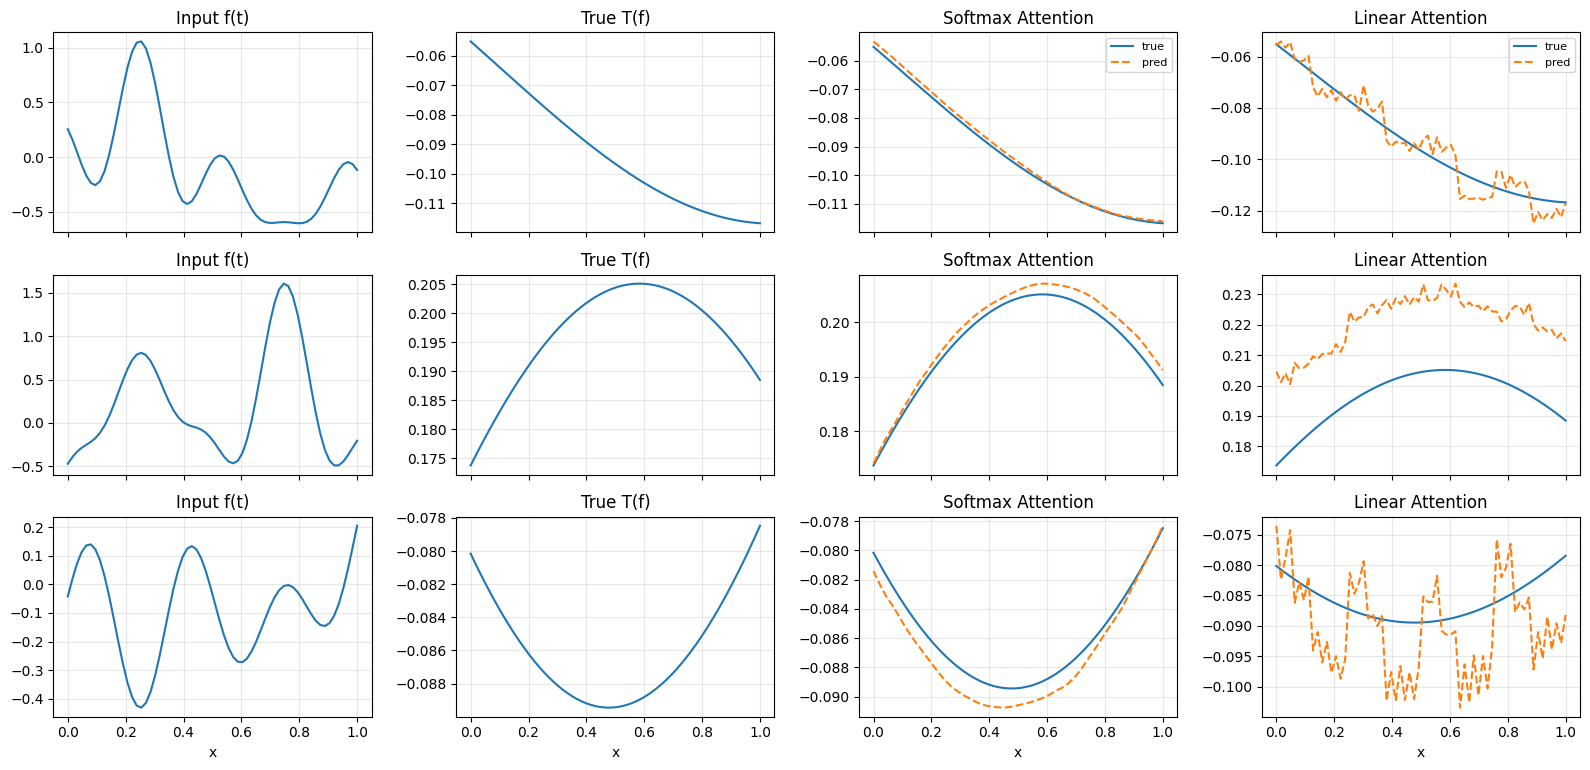

In [ ]:
plot_test_examples(models, test_ds, n_show=3, device=device, idxs=[10, 30, 150])
plt.show()

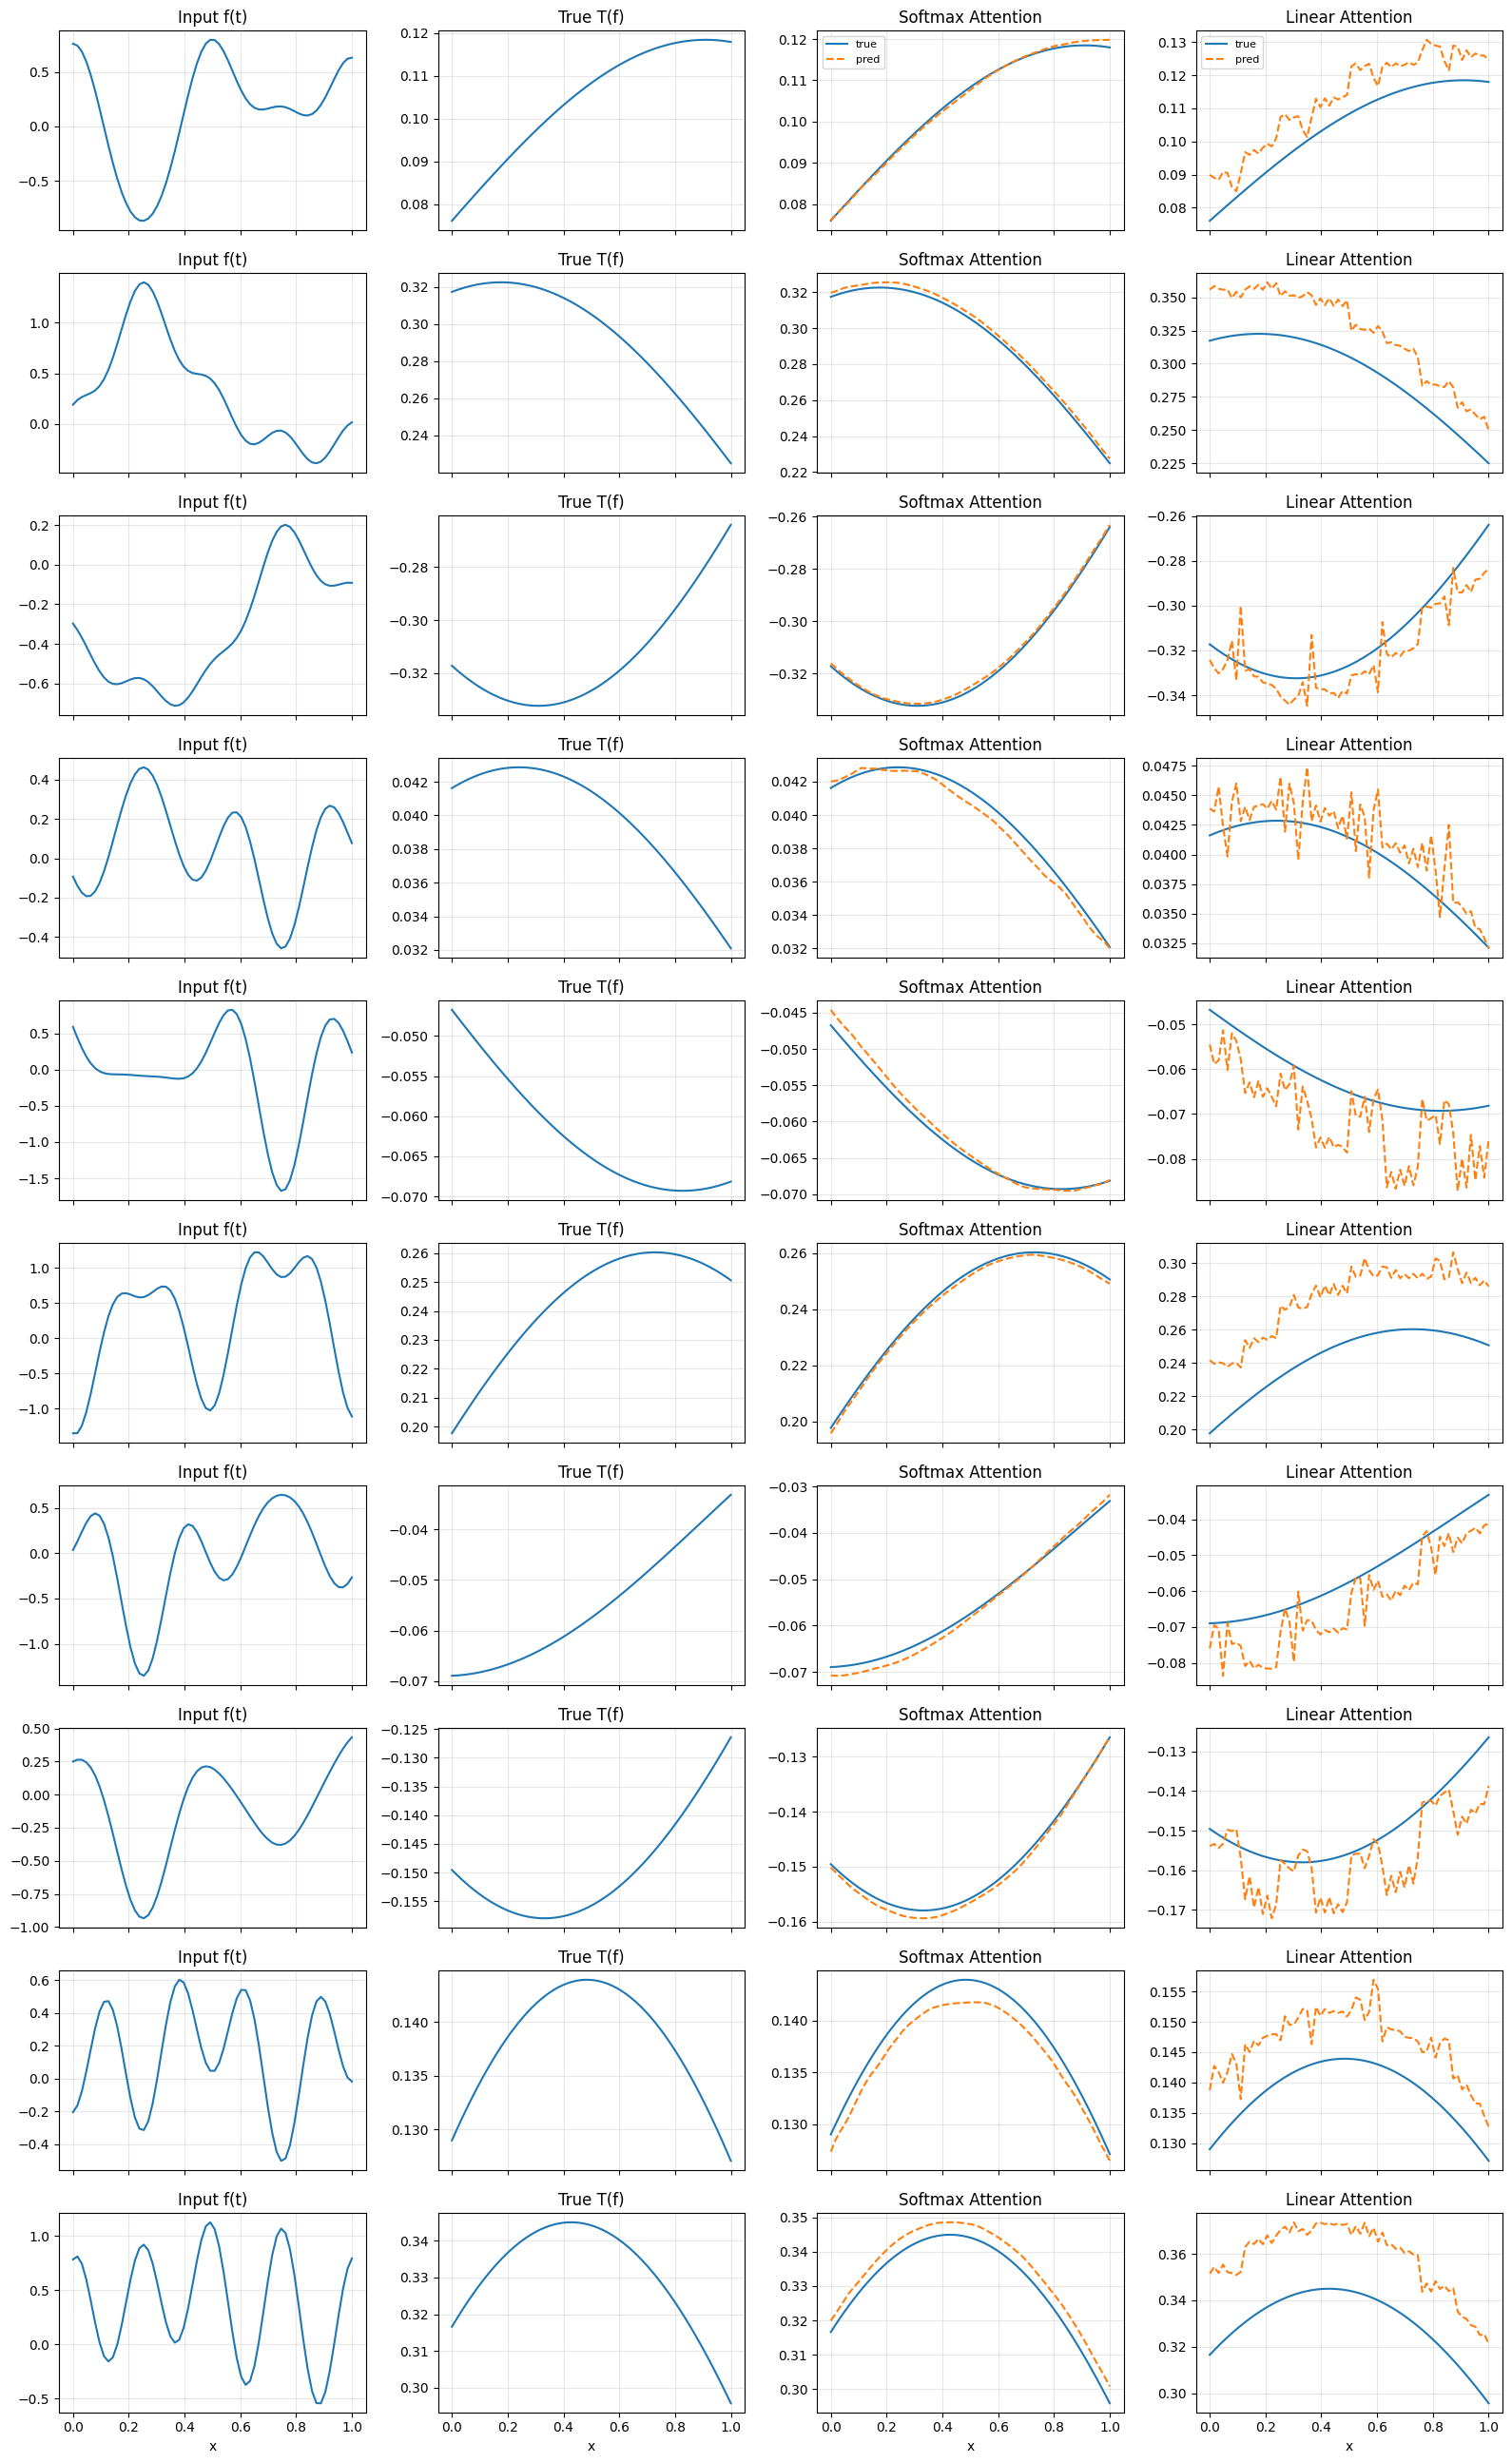

In [ ]:
plot_test_examples(models, test_ds, n_show=10, device=device, idxs=[238,
256,
276,
15,
69,
190,
59,
293,
298,
79])
plt.show()